# Mixer Verification

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rfmodel.core.config import load_yaml
from rfmodel.core.signal import Signal
from rfmodel.core.pipeline_builder import pipeline_from_config
import rfmodel.rf.registry

cfg = load_yaml(r".\PLL_mixer.yaml")
pipe = pipeline_from_config(cfg)

In [2]:
mixer = pipe.get("mixer_and_pll")
mixer.pll = None
mixer.params.mixer_ideal = True

In [3]:
fs = 10e6
N = 2**14
t = np.arange(N) / fs

# --- Tone power levels (change these) ---
P1_dbm = -10.0   # 100 kHz tone
P2_dbm = -10.0   # 300 kHz tone

A1 = np.sqrt(10**((P1_dbm - 30) / 10))
A2 = np.sqrt(10**((P2_dbm - 30) / 10))

x = (
    A1 * np.exp(1j * 2*np.pi*100e3*t) +
    A2 * np.exp(1j * 2*np.pi*300e3*t)
)

sig_in = Signal(x=x, fs_hz=fs, fc_hz=0, meta={})
print(f"Tone 1: {P1_dbm} dBm  (A1 = {A1:.4f})")
print(f"Tone 2: {P2_dbm} dBm  (A2 = {A2:.4f})")

Tone 1: -10.0 dBm  (A1 = 0.0100)
Tone 2: -10.0 dBm  (A2 = 0.0100)


In [4]:
# --- run through mixer only ---
sig_out = mixer(sig_in)
y = sig_out.x

In [5]:
# --- 1. Power preservation test ---
Pin = np.mean(np.abs(x)**2)
Pout = np.mean(np.abs(y)**2)

print("Input power:", Pin)
print("Output power:", Pout)
print("Power ratio (Pout/Pin):", Pout / Pin)

# ideal expectation: ~1.0
assert np.isclose(Pout / Pin, 1.0, atol=1e-6), "Power not preserved → not ideal"

Input power: 0.00019992092263873415
Output power: 0.00019992092263873415
Power ratio (Pout/Pin): 1.0


## Plotting Ideal Mixer Output

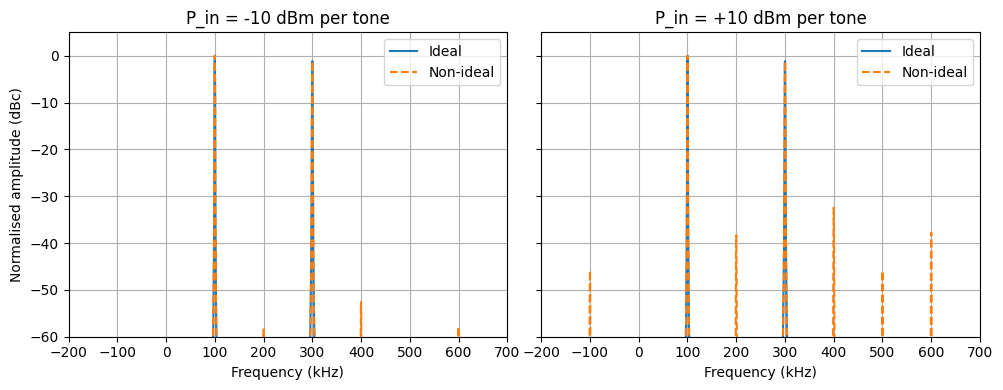

In [6]:
# Compare ideal vs non-ideal mixer output for two input power levels.
# At low power the curves overlap; at high power the non-ideal mixer
# develops intermodulation products.

P_low_dbm  = -10.0   # well below IIP3 — linear regime
P_high_dbm =  10.0   # approaching IIP3 — nonlinear regime

def make_two_tone(P_dbm):
    A = np.sqrt(10**((P_dbm - 30) / 10))
    x = A * np.exp(1j * 2*np.pi*100e3*t) + A * np.exp(1j * 2*np.pi*300e3*t)
    return Signal(x=x, fs_hz=fs, fc_hz=0, meta={})

def run_ideal_and_nonideal(sig):
    # Ideal pass
    mixer.params.mixer_ideal = True
    mixer.pll = None
    y_id = mixer(sig).x
    # Non-ideal pass (turn noise off so we only see distortion products)
    mixer.params.mixer_ideal = False
    nf_save = mixer.params.nf_db
    mixer.params.nf_db = 0
    y_ni = mixer(sig).x
    # Restore
    mixer.params.nf_db = nf_save
    mixer.params.mixer_ideal = True
    return y_id, y_ni

y_id_low,  y_ni_low  = run_ideal_and_nonideal(make_two_tone(P_low_dbm))
y_id_high, y_ni_high = run_ideal_and_nonideal(make_two_tone(P_high_dbm))

# Windowed amplitude spectrum
win     = np.hanning(N)
win_rms = np.sqrt(np.mean(win**2))

def amp_db(sig):
    S = np.fft.fftshift(np.fft.fft(sig * win))
    return 20 * np.log10(np.maximum(np.abs(S) / (N * win_rms), 1e-12))

f_khz = np.fft.fftshift(np.fft.fftfreq(N, 1/fs)) / 1e3

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, y_id, y_ni, P_dbm in [
    (axes[0], y_id_low,  y_ni_low,  P_low_dbm),
    (axes[1], y_id_high, y_ni_high, P_high_dbm),
]:
    P_id = amp_db(y_id); ref_id = np.max(P_id)
    P_ni = amp_db(y_ni); ref_ni = np.max(P_ni)
    ax.plot(f_khz, P_id - ref_id, label='Ideal')
    ax.plot(f_khz, P_ni - ref_ni, '--', label='Non-ideal')
    ax.set_xlabel("Frequency (kHz)")
    ax.set_xlim(-200, 700)
    ax.set_ylim(-60, 5)
    ax.set_title(f"P_in = {P_dbm:+.0f} dBm per tone")
    ax.grid(True)
    ax.legend()
axes[0].set_ylabel("Normalised amplitude (dBc)")
plt.tight_layout()
plt.show()

## Intermodulation Test

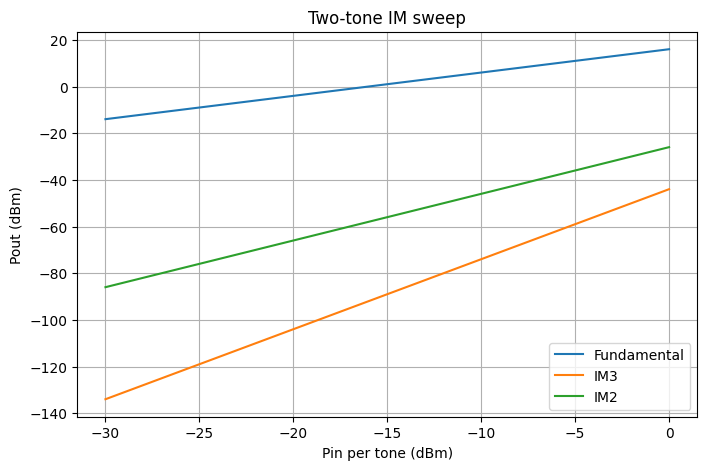

In [7]:
from scipy.signal import hilbert
from rfmodel.core.units import dbm_to_w, w_to_dbm, db_to_linear
from rfmodel.meas.spectrum_analyser import spectrum_analyser

mixer = pipe.get("mixer_and_pll")
mixer.pll = None
mixer.params.mixer_ideal = False
nf_backup = mixer.params.nf_db
mixer.params.nf_db = 0

fs = 5_000_000
t = np.arange(0, 2e-3, 1/fs)

fc = 1e6
f_offset1 = 50_000
f_offset2 = 120_000

# Real two-tone RF signal → complex envelope via Hilbert
rf = np.cos(2*np.pi*(fc + f_offset1)*t) + np.cos(2*np.pi*(fc + f_offset2)*t)
rf_analytic = hilbert(rf)
complex_envelope = rf_analytic * np.exp(-1j * 2*np.pi*fc*t)

combined_two_tone = Signal(
    x=complex_envelope,
    fs_hz=fs,
    fc_hz=fc,
    meta={"name": "two-tone IM test"},
)

# Power sweep
Pin0_W   = np.mean(np.abs(combined_two_tone.x)**2) / 4   # per-tone real power
Pin0_dBm = w_to_dbm(Pin0_W)

Pin_dBm_sweep = np.linspace(-30, 0, 1000)
scale_factors = 10 ** ((Pin_dBm_sweep - Pin0_dBm) / 20.0)

target_f_im3_1 = 2*f_offset1 - f_offset2
target_f_im3_2 = 2*f_offset2 - f_offset1
target_f_im2   = f_offset1 + f_offset2   # sum-frequency IM2 product from a2·x²

Pout_fund_list = []
Pout_IM3_list  = []
Pout_IM2_list  = []

for k in scale_factors:
    sweep_sig = combined_two_tone.copy_with(x=k * combined_two_tone.x)
    sig_out, _ = pipe.run(sweep_sig)

    S_out, freqs = spectrum_analyser(sig_out.x, fs)

    idx_fund_1 = np.argmin(np.abs(freqs - f_offset1))
    idx_fund_2 = np.argmin(np.abs(freqs - f_offset2))
    idx_im3_1  = np.argmin(np.abs(freqs - target_f_im3_1))
    idx_im3_2  = np.argmin(np.abs(freqs - target_f_im3_2))
    idx_im2    = np.argmin(np.abs(freqs - target_f_im2))

    Pout_fund_list.append(w_to_dbm(S_out[idx_fund_1] + S_out[idx_fund_2]))
    Pout_IM3_list.append(w_to_dbm(S_out[idx_im3_1]  + S_out[idx_im3_2]))
    Pout_IM2_list.append(w_to_dbm(S_out[idx_im2]))

Pout_fund_dbm = np.array(Pout_fund_list)
Pout_IM3_dbm  = np.array(Pout_IM3_list)
Pout_IM2_dbm  = np.array(Pout_IM2_list)

plt.figure(figsize=(8, 5))
plt.plot(Pin_dBm_sweep, Pout_fund_dbm, label="Fundamental")
plt.plot(Pin_dBm_sweep, Pout_IM3_dbm,  label="IM3")
plt.plot(Pin_dBm_sweep, Pout_IM2_dbm,  label="IM2")
plt.xlabel("Pin per tone (dBm)")
plt.ylabel("Pout (dBm)")
plt.title("Two-tone IM sweep")
plt.grid(True)
plt.legend()
plt.show()

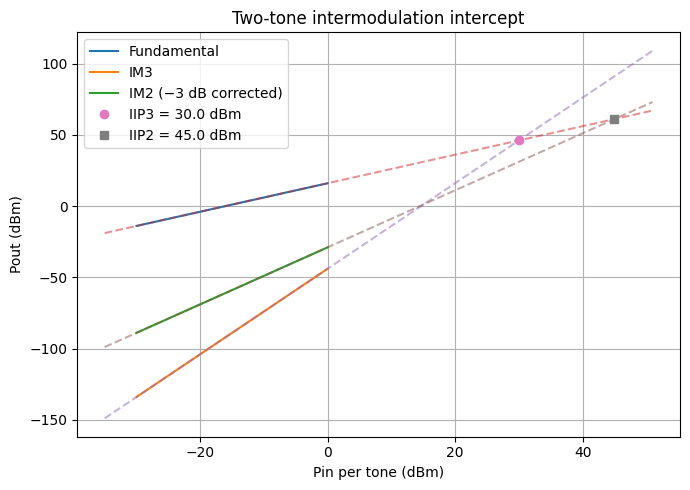

Fundamental slope : 1.000  (expected 1.0)
IM3 slope         : 3.000  (expected 3.0)
IM2 slope         : 2.000  (expected 2.0)
IIP3 measured     : 30.00 dBm  (configured 30.0 dBm)
IIP2 measured     : 44.99 dBm  (configured 45.0 dBm)


In [8]:
# Fit small-signal slopes to extract IIP2 and IIP3.
fit_min, fit_max = -30, -20
mask = (Pin_dBm_sweep >= fit_min) & (Pin_dBm_sweep <= fit_max)

# IM2 from a 2nd-order cross-product (f1+f2) has 2x the amplitude of a
# single-tone 2nd harmonic, i.e. +6 dB in power. Subtracting 3 dB here
# referenced to the summed fundamentals lets the slope intercept directly.
Pout_IM2_corr = Pout_IM2_dbm - 3.0

m_f,  b_f  = np.polyfit(Pin_dBm_sweep[mask], Pout_fund_dbm[mask], 1)
m_i3, b_i3 = np.polyfit(Pin_dBm_sweep[mask], Pout_IM3_dbm[mask],  1)
valid_im2  = np.isfinite(Pout_IM2_corr) & mask
m_i2, b_i2 = np.polyfit(Pin_dBm_sweep[valid_im2], Pout_IM2_corr[valid_im2], 1)

x_iip3 = (b_i3 - b_f) / (m_f - m_i3); y_iip3 = m_f * x_iip3 + b_f
x_iip2 = (b_i2 - b_f) / (m_f - m_i2); y_iip2 = m_f * x_iip2 + b_f

x_ext = np.linspace(-35, max(x_iip2, x_iip3) + 6, 600)

plt.figure(figsize=(7, 5))
plt.plot(Pin_dBm_sweep, Pout_fund_dbm,  label="Fundamental")
plt.plot(Pin_dBm_sweep, Pout_IM3_dbm,   label="IM3")
plt.plot(Pin_dBm_sweep, Pout_IM2_corr,  label="IM2 (−3 dB corrected)")
plt.plot(x_ext, m_f *x_ext + b_f,  '--', alpha=0.5)
plt.plot(x_ext, m_i3*x_ext + b_i3, '--', alpha=0.5)
plt.plot(x_ext, m_i2*x_ext + b_i2, '--', alpha=0.5)
plt.plot(x_iip3, y_iip3, 'o', label=f"IIP3 = {x_iip3:.1f} dBm")
plt.plot(x_iip2, y_iip2, 's', label=f"IIP2 = {x_iip2:.1f} dBm")
plt.xlabel("Pin per tone (dBm)")
plt.ylabel("Pout (dBm)")
plt.title("Two-tone intermodulation intercept")
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f"Fundamental slope : {m_f:.3f}  (expected 1.0)")
print(f"IM3 slope         : {m_i3:.3f}  (expected 3.0)")
print(f"IM2 slope         : {m_i2:.3f}  (expected 2.0)")
print(f"IIP3 measured     : {x_iip3:.2f} dBm  (configured {mixer.params.iip3_dbm} dBm)")
print(f"IIP2 measured     : {x_iip2:.2f} dBm  (configured {mixer.params.iip2_dbm} dBm)")

## Noise Figure Test

SNR input   : 33.7 dB
SNR output  : 28.6 dB
NF from plot: 5.1 dB  (configured: 5.0 dB)


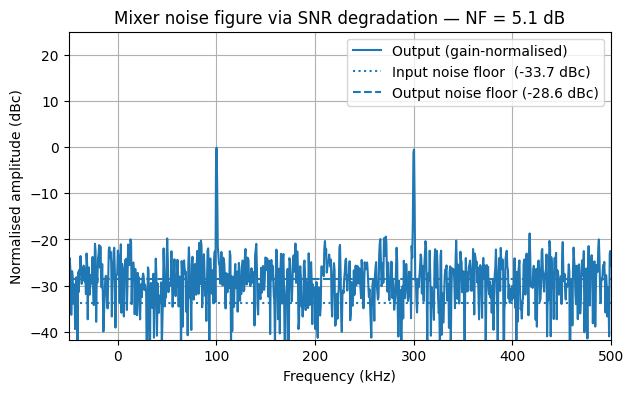

In [9]:
# Noise figure via SNR degradation: drop a clean tone into thermal noise,
# pass it through the (non-ideal) mixer, and read the SNR loss off the
# windowed amplitude spectrum.

fs_nf = 10e6
N_nf  = 2**14
t_nf  = np.arange(N_nf) / fs_nf

kB = 1.380649e-23
T  = mixer.params.temp_k
G  = db_to_linear(mixer.params.gain_db)

mixer.params.mixer_ideal = False
mixer.pll = None
mixer.params.nf_db = nf_backup
mixer._rng = np.random.default_rng(42)   # deterministic for this test

# Thermal noise std-dev per I/Q component
sigma_n = np.sqrt(kB * T * (fs_nf / 2.0) / 2.0)

win     = np.hanning(N_nf)
win_rms = np.sqrt(np.mean(win**2))

SNR_target_dB = 35
A_tone = 10**(SNR_target_dB / 20) * win_rms * sigma_n / (0.5 * np.sqrt(N_nf))

rng      = np.random.default_rng(7)
noise_in = sigma_n * (rng.normal(size=N_nf) + 1j * rng.normal(size=N_nf))
x_tones  = A_tone * (np.exp(1j*2*np.pi*100e3*t_nf) + np.exp(1j*2*np.pi*300e3*t_nf))
x_in_nf  = x_tones + noise_in

x_out_nf   = mixer(Signal(x=x_in_nf, fs_hz=fs_nf, fc_hz=0, meta={})).x
x_out_norm = x_out_nf / np.sqrt(G)   # remove mixer gain

def amp_db(s):
    S = np.fft.fftshift(np.fft.fft(s * win))
    return 20 * np.log10(np.maximum(np.abs(S) / (N_nf * win_rms), 1e-12))

f_khz = np.fft.fftshift(np.fft.fftfreq(N_nf, 1/fs_nf)) / 1e3
P_in  = amp_db(x_in_nf)
P_out = amp_db(x_out_norm)
ref   = np.max(amp_db(x_tones))   # use clean tones as deterministic reference

mask = (np.abs(f_khz - 100) > 60) & (np.abs(f_khz - 300) > 60) & (np.abs(f_khz) < 480)
floor_in_dBc  = np.median(P_in[mask])  - ref
floor_out_dBc = np.median(P_out[mask]) - ref
NF_est = floor_out_dBc - floor_in_dBc

print(f"SNR input   : {-floor_in_dBc:.1f} dB")
print(f"SNR output  : {-floor_out_dBc:.1f} dB")
print(f"NF from plot: {NF_est:.1f} dB  (configured: {mixer.params.nf_db} dB)")

plt.figure(figsize=(7, 4))
plt.plot(f_khz, P_out - ref, label='Output (gain-normalised)')
plt.axhline(floor_in_dBc,  ls=':',  label=f'Input noise floor  ({floor_in_dBc:.1f} dBc)')
plt.axhline(floor_out_dBc, ls='--', label=f'Output noise floor ({floor_out_dBc:.1f} dBc)')
plt.xlabel("Frequency (kHz)")
plt.ylabel("Normalised amplitude (dBc)")
plt.title(f"Mixer noise figure via SNR degradation — NF = {NF_est:.1f} dB")
plt.xlim(-50, 500)
plt.ylim(floor_in_dBc - 8, 25)
plt.grid(True)
plt.legend()
plt.show()